# Introduction to Generative Adversarial Networks (GANs)

In this notebook, we will introduce Generative Adversarial Networks (GANs) and implement a simple GAN using PyTorch. We will first discuss the basic concepts of GANs and training models on 2D data. Then, we will implement a GAN to generate handwritten digits from the MNIST dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader

import torchvision.transforms as transforms
import torchvision.datasets as datasets

First let us define the device to work on:

In [27]:
print(f"GPU available using Cuda: {torch.cuda.is_available()}")
print(
    f"GPU available using MPS: {torch.backends.mps.is_available() and torch.backends.mps.is_built()}"
)
if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_available = True
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
    gpu_available = True
else:
    device = torch.device("cpu")
    gpu_available = False


print(f"Device: {device}")
print(f"Number of GPUs: {torch.cuda.device_count()}")

GPU available using Cuda: False
GPU available using MPS: True
Device: mps
Number of GPUs: 0


# 1 The GAN Model

Generative Adversarials Networks (GANs) are a class of generative models that are used to generate new data samples. GANs consist of two neural networks, a generator and a discriminator, that are trained simultaneously. The generator generates new data samples, while the discriminator tries to distinguish between real and generated samples. The generator and discriminator are trained in an adversarial manner, where the generator tries to generate samples that are indistinguishable from real samples, and the discriminator tries to distinguish between real and generated samples.

## 1.1 The Generator

One easy way to thing about the generator is as a function that takes random noise as input and generates new data samples. The generator is a neural network that takes random noise as input and generates new data samples. The generator is trained to generate samples that are indistinguishable from real samples. 

Typically the generator is a feedforward neural network that takes random noise as input in $R^d$ and generates samples in $R^D$. The distribution of the output is the generated distribution. Typically, the input noise is sampled from a normal distribution and for instance, if the generator function is linear:


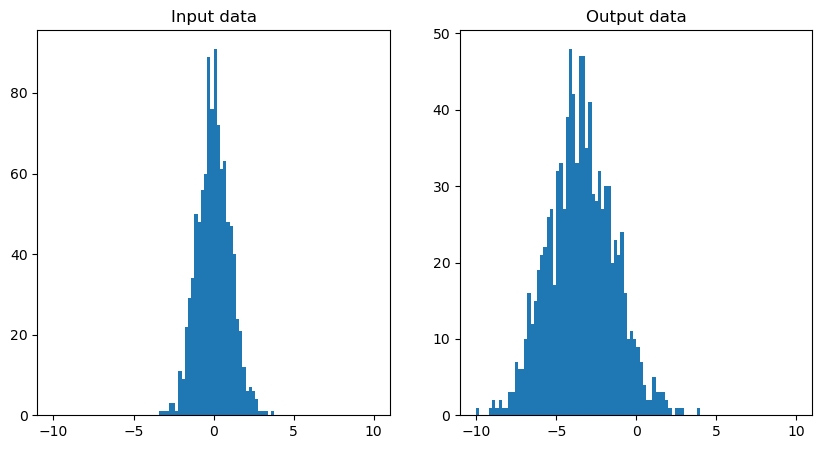

In [3]:
def input_noise(n=1000, noise_dim=1):
    return torch.randn(n, noise_dim)


def generator_function(x):
    return 2 * x - 3.5


input_data = input_noise()
output_data = generator_function(input_data)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(input_data.numpy(), bins=100, range=(-10, 10))
plt.title("Input data")
plt.subplot(1, 2, 2)
plt.hist(output_data.numpy(), bins=100, range=(-10, 10))
plt.title("Output data")
plt.show()

The generator can be implemented with a neural network to represent more complex functions.

## 1.2 The Discriminator

Let us assume that we have a target distribution $p_{\text{data}}(x)$ and a generator distribution $p_{\text{model}}(x)$. The discriminator is trained to distinguish between samples from the target distribution and the generator distribution. The discriminator is trained to differentiate between samples from the target distribution and the generator distribution. In other words, the discriminator outputs the probability that a sample is from the target distribution:

In [4]:
def target_density(x):
    return 0.5 * torch.exp(
        torch.distributions.Normal(-4, 1).log_prob(x)
    ) + 0.5 * torch.exp(torch.distributions.Normal(4, 1).log_prob(x))


def model_density(x):
    return torch.exp(torch.distributions.Normal(-3.5, 2).log_prob(x))

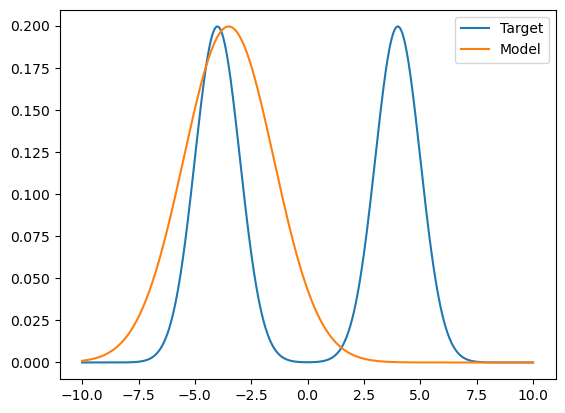

In [5]:
x = torch.linspace(-10, 10, 1000)
plt.plot(x, target_density(x), label="Target")
plt.plot(x, model_density(x), label="Model")
plt.legend()

The optimal discriminator is given by:
$$D^*(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_{\text{model}}(x)}$$

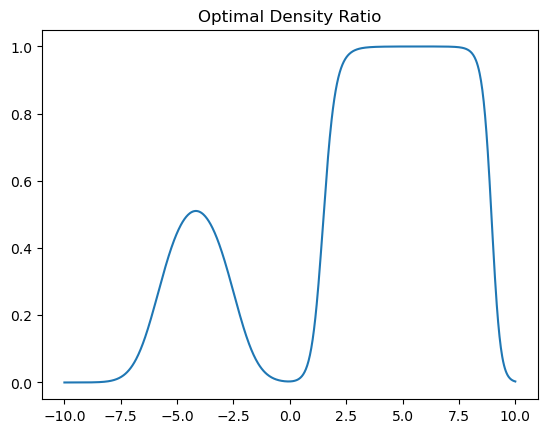

In [6]:
Dopt = target_density(x) / (target_density(x) + model_density(x) + 1e-6)
plt.figure()
plt.plot(x, Dopt)
plt.title("Optimal Density Ratio")
plt.show()

The Generator is trained to generate samples that are indistinguishable from samples from the target distribution. In other words, the generator tries to generate samples with the highest probability of being from the target distribution.
We will now implement a simple GAN on 2D data.

# 2. GAN on two dimensional data Gaussian Mixture

In this section, we will implement a simple GAN on 2D data. We will generate samples from a Gaussian Mixture distribution and train a GAN to generate samples from the same distribution using PyTorch.
We will implement a linear generator and discriminator for this task, then move on to more complex models. 


## 1.1 Training loop on simple data with linear models

First let us visualize the data:

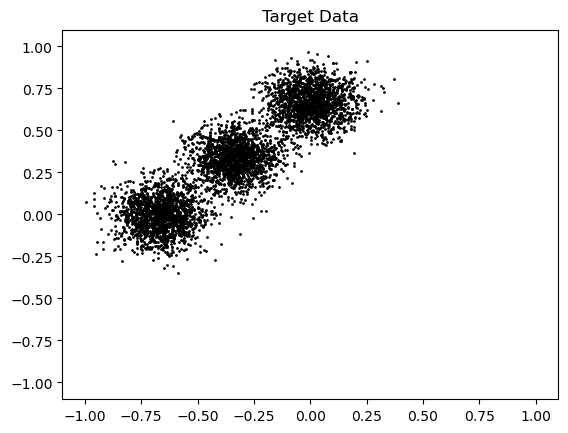

In [7]:
def simple_2D_data(n=1000):
    means = torch.Tensor([[-4, 0], [0, 4], [-2, 2]])
    sigmas = torch.Tensor([0.6] * 3)
    n_per_cluster = n // 3
    data = []
    for i in range(3):
        data.append(
            torch.distributions.Normal(means[i], sigmas[i]).sample((n_per_cluster,))
        )
    data = torch.cat(data) / 6
    return data


dataset = simple_2D_data(n=5000)
plt.scatter(dataset[:, 0], dataset[:, 1], c="black", s=1)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.title("Target Data")
plt.show()

<font color='blue'>**TODO:**</font> Complete the code below to implement a linear generator and discriminator:
- The generator should be a linear layer that takes an input noise in dimension `noise_dim` and outputs a sample in dimension 2. You can add output activation if needed.
- The discriminator should be a linear layer that takes an input sample in dimension 2 and outputs a probability that the sample is from the target distribution. The output should be a scalar between 0 and 1. You can add output activation if needed.

```python

In [11]:
class LinearGenerator(nn.Module):
    def __init__(self, noise_dim=1):
        super(LinearGenerator, self).__init__()
        self.fc = nn.Linear(noise_dim, 2)
        self.output_activation = nn.Tanh()

    def forward(self, x):
        x = self.fc(x)
        return self.output_activation(x)


class LinearDiscriminator(nn.Module):
    def __init__(self):
        super(LinearDiscriminator, self).__init__()
        self.fc = nn.Linear(2, 1) 
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        x = self.fc(x)
        return self.output_activation(x)

Let us the both models:

In [12]:
def visualize_generator(generator, noise_dim, n=1000):
    noise = input_noise(n, noise_dim=noise_dim).to(device)
    generated_data = generator(noise).detach().cpu()
    plt.figure()
    plt.scatter(generated_data[:, 0], generated_data[:, 1], c="blue", s=1)
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.title("Generated Data")
    plt.show()


def visualize_discriminator(discriminator, n=1000):
    x = torch.linspace(-1, 1, n)
    y = torch.linspace(-1, 1, n)
    xx, yy = torch.meshgrid(x, y)
    grid = (
        torch.from_numpy(np.stack([xx, yy], axis=-1).reshape(-1, 2)).float().to(device)
    )
    with torch.no_grad():
        predictions = discriminator(grid).cpu().view(n, n)
    plt.imshow(predictions.T, extent=(-1, 1, -1, 1), origin="lower")
    plt.colorbar()
    plt.title("Discriminator Output")
    plt.show()


def visualize_loss(loss_D, loss_G):
    plt.figure()
    plt.plot(loss_D, label="Discriminator Loss")
    plt.plot(loss_G, label="Generator Loss")
    plt.legend()
    plt.title("Losses")
    plt.show()

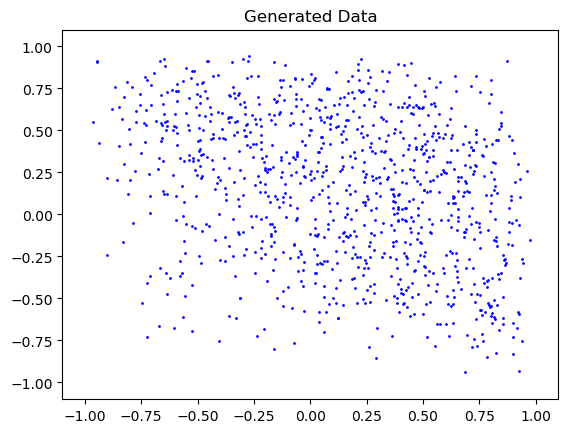

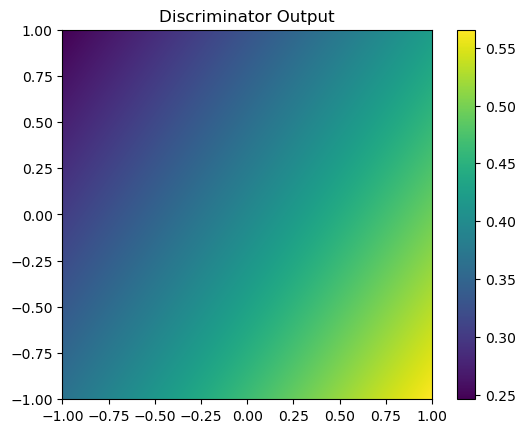

In [17]:
noise_dim = 10
generator = LinearGenerator(noise_dim).to(device)
discriminator = LinearDiscriminator().to(device)

visualize_generator(generator, noise_dim)
visualize_discriminator(discriminator)

Since the discriminator is trained to differentiate between samples from the target distribution and the generator distribution, we can train it as a binary classifier. Let us say that the point from the target distribution is labeled as 1 and the point from the generator distribution is labeled as 0.

<font color='blue'>**TODO:**</font> Complete the code below to implement the training loss for the discriminator using the binary cross entropy loss ```torch.nn.BCELoss``` [(Doc)](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html). The discriminator should output the probability that the sample is from the target distribution. The target should be 1 for samples from the target distribution and 0 for samples from the generator distribution.


In [18]:
criterion = nn.BCELoss()


def discriminator_loss(output_real, output_fake):
    real_labels = torch.ones_like(output_real)
    fake_labels = torch.zeros_like(output_fake)

    real_loss = criterion(output_real, real_labels)
    fake_loss = criterion(output_fake, fake_labels)

    return real_loss + fake_loss

The generator loss is the opposite of the discriminator loss. We can write it as the Binary Cross Entropy loss with the labels flipped.

<font color='blue'>**TODO:**</font> Complete the code below to implement the training loss for the generator. 



In [19]:
def generator_loss(output_fake):
    fake_labels = torch.ones_like(output_fake)  
    fake_loss = criterion(output_fake, fake_labels) 
    return fake_loss

<font color='blue'>**TODO:**</font>  Run the code below to make sure that the training losses are implemented correctly.


In [20]:
noise_dim = 10
noise = input_noise(1000, noise_dim=noise_dim).to(device)
data = simple_2D_data(n=5000).to(device)

generator = LinearGenerator(noise_dim).to(device)
discriminator = LinearDiscriminator().to(device)

print(
    "The discriminator loss is: ",
    discriminator_loss(discriminator(data), discriminator(generator(noise))),
)
print("The generator loss is: ", generator_loss(discriminator(generator(noise))))

The discriminator loss is:  tensor(1.2727, device='mps:0', grad_fn=<AddBackward0>)
The generator loss is:  tensor(0.9169, device='mps:0', grad_fn=<BinaryCrossEntropyBackward0>)


The training loop for the GAN consists in alternating a gradient step on the discriminator and the generator:
1. Sample a batch a data from the target distribution.
2. Sample a batch of noise from a normal distribution with the same batch size.
3. Generate samples from the generator.
4. Compute the discriminator loss based on real and generated samples.
5. Apply a gradient step on the discriminator.
6. Compute the generator loss based on generated samples.
7. Apply a gradient step on the generator.

<font color='blue'>**TODO:**</font> Complete the code below to implement the training step for the GAN. The training step should apply a gradient step on the discriminator and the generator. The training step should return the discriminator and generator losses.  The training step should be able to apply a gradient step on the discriminator `num_steps` times before applying a gradient step on the generator.

In [42]:
def training_step(generator, discriminator, optimizer_D, optimizer_G, noise, data, num_steps=1):
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

    for _ in range(num_steps):
        discriminator.train()
        generator.eval()
        optimizer_D.zero_grad()

        generated_data = generator(noise)
        output_real = discriminator(data)
        output_fake = discriminator(generated_data) 

        loss_D = discriminator_loss(output_real, output_fake)
        loss_D.backward()
        optimizer_D.step()

    discriminator.eval()
    generator.train()

    optimizer_G.zero_grad()
    generated_data = generator(noise)
    output_fake = discriminator(generated_data)
    loss_G = generator_loss(output_fake)
    loss_G.backward()
    optimizer_G.step()
    
    return loss_D.item(), loss_G.item()


<font color='blue'>**TODO:**</font> Run the code below to make sure that the training step is implemented correctly.

In [43]:
noise_dim = 10
batch_size = 100

generator = LinearGenerator(noise_dim).to(device)
discriminator = LinearDiscriminator().to(device)

optimizer_D = optim.Adam(discriminator.parameters(), lr=0.002)
optimizer_G = optim.Adam(generator.parameters(), lr=0.002)

noise = input_noise(n=batch_size, noise_dim=noise_dim).to(device)
data = simple_2D_data(n=batch_size).to(device)

print("Before training")
print(
    "The discriminator loss is: ",
    discriminator_loss(discriminator(data), discriminator(generator(noise))),
)
print("The generator loss is: ", generator_loss(discriminator(generator(noise))))

for _ in range(100):
    loss_D, loss_G = training_step(
        generator, discriminator, optimizer_D, optimizer_G, noise, data
    )

print("\nAfter a few training steps")
print(
    "The discriminator loss is: ",
    discriminator_loss(discriminator(data), discriminator(generator(noise))),
)
print("The generator loss is: ", generator_loss(discriminator(generator(noise))))

Before training
The discriminator loss is:  tensor(1.5368, device='mps:0', grad_fn=<AddBackward0>)
The generator loss is:  tensor(1.0918, device='mps:0', grad_fn=<BinaryCrossEntropyBackward0>)

After a few training steps
The discriminator loss is:  tensor(1.4304, device='mps:0', grad_fn=<AddBackward0>)
The generator loss is:  tensor(0.9350, device='mps:0', grad_fn=<BinaryCrossEntropyBackward0>)


<font color='blue'>**TODO:**</font>  Complete the code below to implement the training loop for the GAN. At each epoch, we should sample 5000 data points from the target distribution and split them into batches of size `batch_size`. 

In [50]:
def train_GAN(
    generator,
    discriminator,
    optimizer_D,
    optimizer_G,
    noise_dim,
    sample_function,
    n_epochs=20,
    batch_size=100,
    num_steps=1,
):
    loss_D_values = []
    loss_G_values = []
    noise = input_noise(n=5000, noise_dim=noise_dim).to(device)
    data = sample_function(5000).to(device) 
    n_batches = len(data) // batch_size
    for epoch in range(n_epochs):
        data = data[torch.randperm(len(data))]
        noise = noise[torch.randperm(len(noise))]
        avg_loss_D = 0
        avg_loss_G = 0

        for i in range(n_batches):
            noise_i = noise[i * batch_size:(i + 1) * batch_size]
            data_i = data[i * batch_size:(i + 1) * batch_size] 
            loss_D, loss_G = training_step(
                generator, discriminator, optimizer_D, optimizer_G, noise_i, data_i, num_steps
            )
            loss_D_values.append(loss_D)
            loss_G_values.append(loss_G)
            avg_loss_D += loss_D
            avg_loss_G += loss_G

        print(
            f"Epoch {epoch+1}/{n_epochs} Loss D: {avg_loss_D/n_batches:.4f} Loss G: {avg_loss_G/n_batches:.4f}"
        )

    return loss_D_values, loss_G_values

<font color='blue'>**TODO:**</font> Run the code below to train the GAN on 2D data.

In [53]:
generator = LinearGenerator(noise_dim).to(device)
discriminator = LinearDiscriminator().to(device)

optimizer_D = optim.Adam(discriminator.parameters(), betas=(0.5, 0.9), lr=5e-4)
optimizer_G = optim.Adam(generator.parameters(), betas=(0.5, 0.9), lr=5e-4)

loss_D_values, loss_G_values = train_GAN(
    generator,
    discriminator,
    optimizer_D,
    optimizer_G,
    noise_dim,
    simple_2D_data,
    n_epochs=20,
    batch_size=100,
    num_steps=5,
)

Epoch 1/20 Loss D: 1.5004 Loss G: 0.7699
Epoch 2/20 Loss D: 1.4381 Loss G: 0.7115
Epoch 3/20 Loss D: 1.3885 Loss G: 0.6947
Epoch 4/20 Loss D: 1.3447 Loss G: 0.7173
Epoch 5/20 Loss D: 1.3041 Loss G: 0.7430
Epoch 6/20 Loss D: 1.2699 Loss G: 0.7678
Epoch 7/20 Loss D: 1.2420 Loss G: 0.7925
Epoch 8/20 Loss D: 1.2200 Loss G: 0.8133
Epoch 9/20 Loss D: 1.2028 Loss G: 0.8334
Epoch 10/20 Loss D: 1.1897 Loss G: 0.8493
Epoch 11/20 Loss D: 1.1791 Loss G: 0.8559
Epoch 12/20 Loss D: 1.1723 Loss G: 0.8640
Epoch 13/20 Loss D: 1.1688 Loss G: 0.8606
Epoch 14/20 Loss D: 1.1692 Loss G: 0.8555
Epoch 15/20 Loss D: 1.1740 Loss G: 0.8434
Epoch 16/20 Loss D: 1.1848 Loss G: 0.8309
Epoch 17/20 Loss D: 1.1990 Loss G: 0.8141
Epoch 18/20 Loss D: 1.2207 Loss G: 0.7948
Epoch 19/20 Loss D: 1.2484 Loss G: 0.7727
Epoch 20/20 Loss D: 1.2828 Loss G: 0.7507


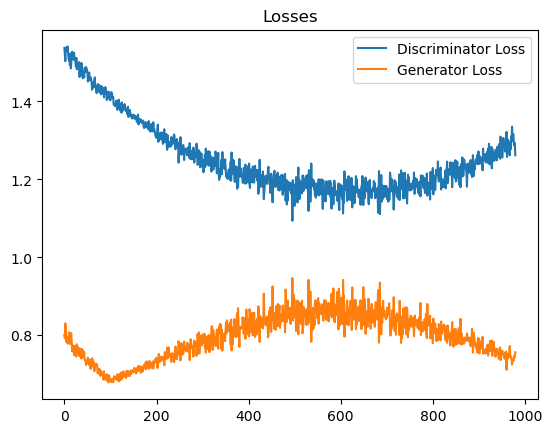

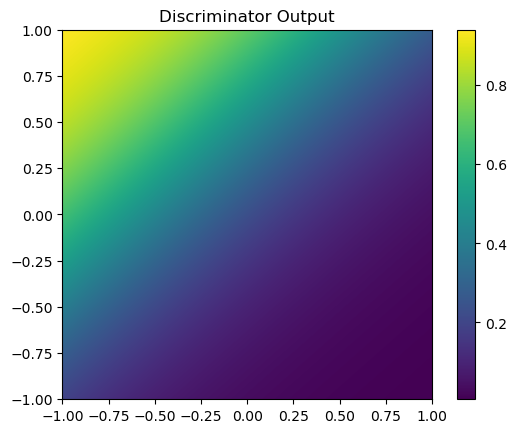

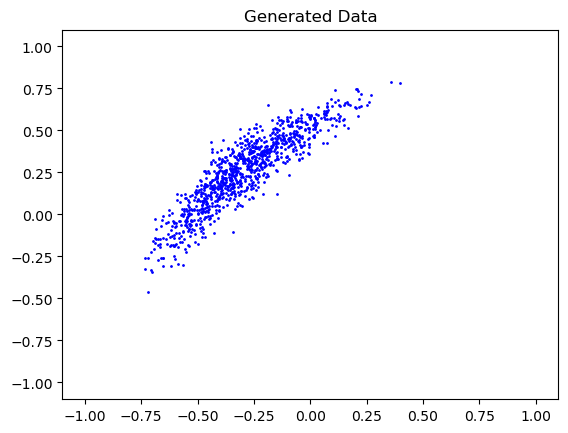

In [54]:
visualize_loss(loss_D_values, loss_G_values)
visualize_discriminator(discriminator)
visualize_generator(generator, noise_dim)

Let us try with a more complex model:

<font color='blue'>**TODO:**</font> Complete the code below to implement a more complex generator and discriminator:
- Generator: Implement a neural network with 4 hidden layers of size 256, 512, 1024 with Leaky ReLU activation functions. The output layer should output a sample in dimension 2.
- Discriminator: Implement a neural network with 4 hidden layers of size 1024, 512, 256 with Leaky ReLU activation functions. The output layer should output a scalar between 0 and 1.

In [ ]:
class DenseGenerator(nn.Module):
    def __init__(self, noise_dim=1, out_dim=2):
        super(DenseGenerator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, out_dim),
            nn.Tanh()  
        )

    def forward(self, x):
        return self.model(x)

class DenseDiscriminator(nn.Module):
    def __init__(self, in_dim=2):
        super(DenseDiscriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(in_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        return self.model(x)

In [70]:
class DenseGenerator(nn.Module):
    def __init__(self, noise_dim=1, out_dim=2):
        super(DenseGenerator, self).__init__()

        self.fc1 = nn.Linear(noise_dim, 256)
        self.fc2 = nn.Linear(256, 512)  
        self.fc3 = nn.Linear(512, 1024)
        self.fc4 = nn.Linear(1024, out_dim)
        self.output_activation = nn.Tanh()

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = F.leaky_relu(self.fc3(x))
        return self.output_activation(self.fc4(x))

class DenseDiscriminator(nn.Module):
    def __init__(self, in_dim=2):
        super(DenseDiscriminator, self).__init__()

        self.fc1 = nn.Linear(in_dim, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 1)
        self.output_activation = nn.Sigmoid()


    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = F.leaky_relu(self.fc3(x))
        return self.output_activation(self.fc4(x))
    

<font color='blue'>**TODO:**</font> Run the code below to train the GAN on 2D data with a more complex model. Observe the generated samples and the discriminator. 

In [71]:
noise_dim = 10
batch_size = 100

generator = DenseGenerator(noise_dim).to(device)
discriminator = DenseDiscriminator().to(device)

optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)

loss_D_values, loss_G_values = train_GAN(
    generator,
    discriminator,
    optimizer_D,
    optimizer_G,
    noise_dim,
    simple_2D_data,
    n_epochs=20,
    batch_size=100,
    num_steps=5,
)

Epoch 1/20 Loss D: 0.6717 Loss G: 2.5381
Epoch 2/20 Loss D: 0.9283 Loss G: 2.2253
Epoch 3/20 Loss D: 1.1001 Loss G: 1.5128
Epoch 4/20 Loss D: 1.1112 Loss G: 1.1678
Epoch 5/20 Loss D: 1.2789 Loss G: 0.8478
Epoch 6/20 Loss D: 1.1987 Loss G: 0.8794
Epoch 7/20 Loss D: 1.2457 Loss G: 0.8728
Epoch 8/20 Loss D: 1.2996 Loss G: 0.7866
Epoch 9/20 Loss D: 1.3138 Loss G: 0.7807
Epoch 10/20 Loss D: 1.3421 Loss G: 0.7511
Epoch 11/20 Loss D: 1.3593 Loss G: 0.7403
Epoch 12/20 Loss D: 1.3535 Loss G: 0.7366
Epoch 13/20 Loss D: 1.3497 Loss G: 0.7490
Epoch 14/20 Loss D: 1.3595 Loss G: 0.7375
Epoch 15/20 Loss D: 1.3603 Loss G: 0.7382
Epoch 16/20 Loss D: 1.3654 Loss G: 0.7286
Epoch 17/20 Loss D: 1.3627 Loss G: 0.7302
Epoch 18/20 Loss D: 1.3537 Loss G: 0.7499
Epoch 19/20 Loss D: 1.3050 Loss G: 0.8148
Epoch 20/20 Loss D: 1.2410 Loss G: 0.9183


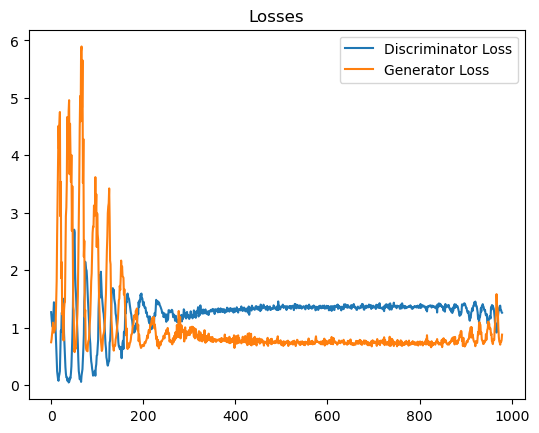

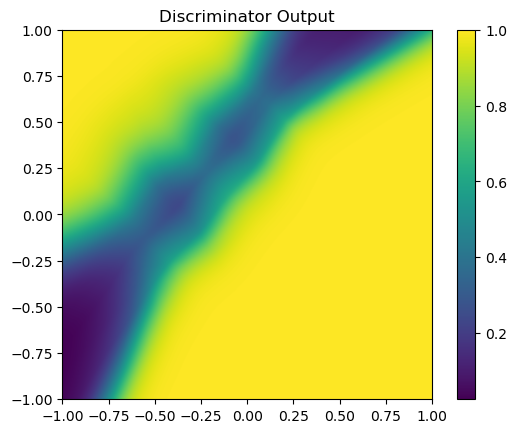

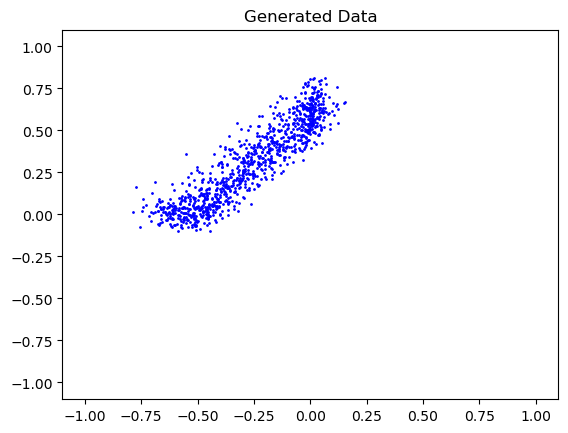

In [72]:
visualize_loss(loss_D_values, loss_G_values)
visualize_discriminator(discriminator)
visualize_generator(generator, noise_dim)

We will now try with 2D data slightly more complex:

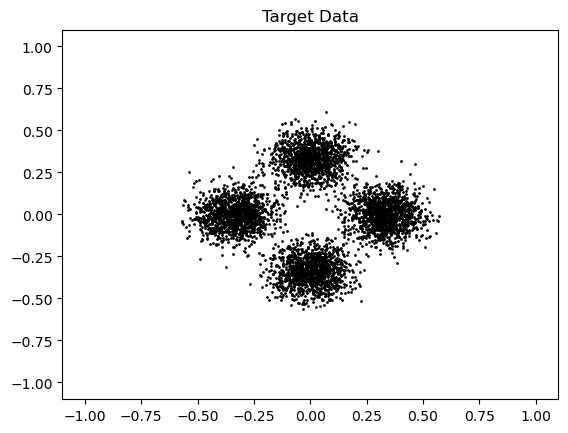

In [73]:
def complex_2D_data(n=1000):
    means = torch.Tensor([[-2, 0], [2, 0], [0, 2], [0, -2]])
    sigmas = torch.Tensor([0.5] * 4)
    n_per_cluster = n // 4
    data = []
    for i in range(4):
        data.append(
            torch.distributions.Normal(means[i], sigmas[i]).sample((n_per_cluster,))
        )
    data = torch.cat(data) / 6
    return data


dataset = complex_2D_data(n=5000)
plt.scatter(dataset[:, 0], dataset[:, 1], c="black", s=1)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.title("Target Data")
plt.show()

<font color='blue'>**TODO:**</font> Run the code below to train the GAN on 2D data with a more complex model. Observe the generated samples and the discriminator.

In [74]:
noise_dim = 10
batch_size = 100

generator = DenseGenerator(noise_dim).to(device)
discriminator = DenseDiscriminator().to(device)

optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)

loss_D_values, loss_G_values = train_GAN(
    generator,
    discriminator,
    optimizer_D,
    optimizer_G,
    noise_dim,
    complex_2D_data,
    n_epochs=20,
    batch_size=100,
    num_steps=5,
)

Epoch 1/20 Loss D: 0.9316 Loss G: 1.2968
Epoch 2/20 Loss D: 0.9419 Loss G: 1.5353
Epoch 3/20 Loss D: 1.1319 Loss G: 1.1943
Epoch 4/20 Loss D: 1.2240 Loss G: 1.0266
Epoch 5/20 Loss D: 1.3009 Loss G: 0.8775
Epoch 6/20 Loss D: 1.3289 Loss G: 0.8186
Epoch 7/20 Loss D: 1.3100 Loss G: 0.8286
Epoch 8/20 Loss D: 1.2355 Loss G: 0.9511
Epoch 9/20 Loss D: 1.2403 Loss G: 0.9670
Epoch 10/20 Loss D: 1.2321 Loss G: 0.9571
Epoch 11/20 Loss D: 1.2965 Loss G: 0.8719
Epoch 12/20 Loss D: 1.3413 Loss G: 0.7829
Epoch 13/20 Loss D: 1.3561 Loss G: 0.7713
Epoch 14/20 Loss D: 1.3422 Loss G: 0.7864
Epoch 15/20 Loss D: 1.3107 Loss G: 0.8252
Epoch 16/20 Loss D: 1.3313 Loss G: 0.8034
Epoch 17/20 Loss D: 1.3094 Loss G: 0.7868
Epoch 18/20 Loss D: 1.2775 Loss G: 0.8525
Epoch 19/20 Loss D: 1.2531 Loss G: 0.8975
Epoch 20/20 Loss D: 1.3163 Loss G: 0.8397


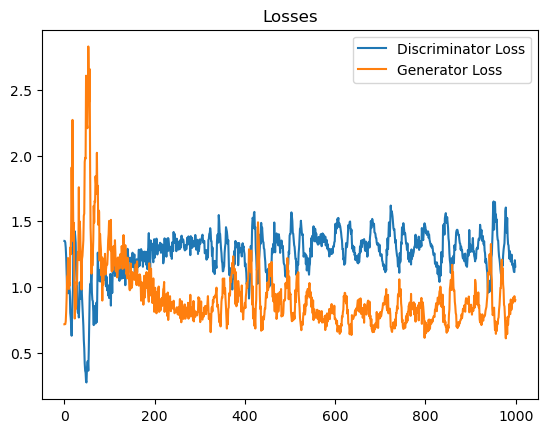

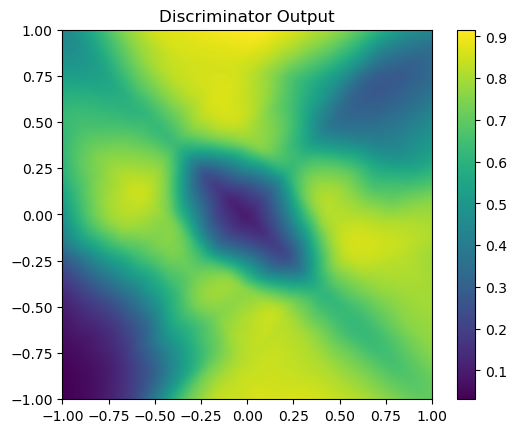

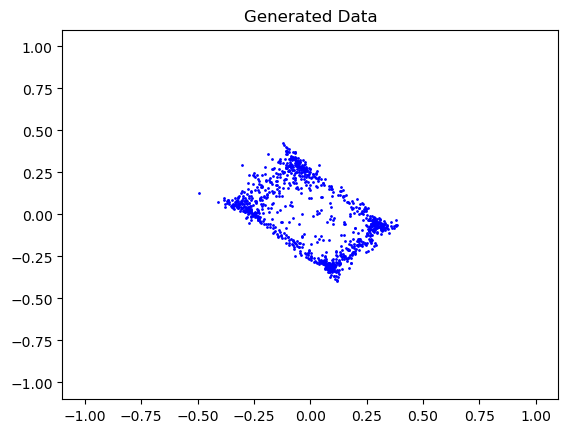

In [75]:
visualize_loss(loss_D_values, loss_G_values)
visualize_discriminator(discriminator)
visualize_generator(generator, noise_dim)

The GAN model is know for being hard to train for two main reasons:
- Mode collapse: The generator collapses to a single point and generates the same sample.
- Model instability: The generator and discriminator are trained simultaneously and the training can be unstable.

We can observe the model collapse easilly with the 2D data on this dataset:


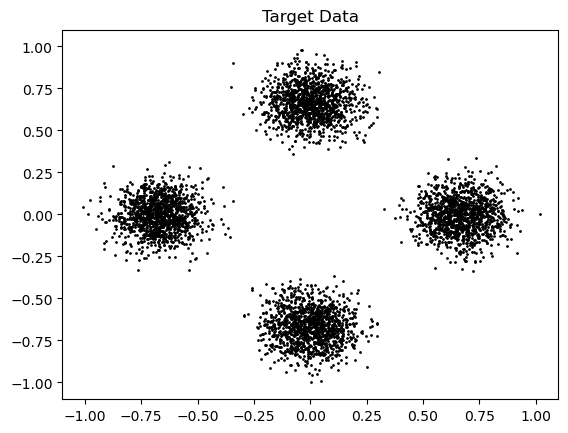

In [76]:
def complex_large_2D_data(n=1000):
    means = torch.Tensor([[-4, 0], [4, 0], [0, 4], [0, -4]])
    sigmas = torch.Tensor([0.6] * 4)
    n_per_cluster = n // 4
    data = []
    for i in range(4):
        data.append(
            torch.distributions.Normal(means[i], sigmas[i]).sample((n_per_cluster,))
        )
    data = torch.cat(data) / 6
    return data


dataset = complex_large_2D_data(n=5000)
plt.scatter(dataset[:, 0], dataset[:, 1], c="black", s=1)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.title("Target Data")
plt.show()

<font color='blue'>**TODO:**</font> Run the code below to train the GAN on 2D data with a more complex model. Conclude on mode collapse.

In [77]:
noise_dim = 10
batch_size = 100

generator = DenseGenerator(noise_dim).to(device)
discriminator = DenseDiscriminator().to(device)

optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)

loss_D_values, loss_G_values = train_GAN(
    generator,
    discriminator,
    optimizer_D,
    optimizer_G,
    noise_dim,
    complex_large_2D_data,
    n_epochs=20,
    batch_size=100,
    num_steps=5,
)

Epoch 1/20 Loss D: 0.5457 Loss G: 2.7694
Epoch 2/20 Loss D: 0.7711 Loss G: 2.1957
Epoch 3/20 Loss D: 0.8604 Loss G: 1.9194
Epoch 4/20 Loss D: 0.7811 Loss G: 2.0620
Epoch 5/20 Loss D: 0.8382 Loss G: 1.8951
Epoch 6/20 Loss D: 0.9314 Loss G: 1.4630
Epoch 7/20 Loss D: 0.9361 Loss G: 1.3324
Epoch 8/20 Loss D: 0.9172 Loss G: 1.3954
Epoch 9/20 Loss D: 0.8674 Loss G: 1.5846
Epoch 10/20 Loss D: 0.8680 Loss G: 1.6142
Epoch 11/20 Loss D: 0.9024 Loss G: 1.5450
Epoch 12/20 Loss D: 0.8481 Loss G: 1.5864
Epoch 13/20 Loss D: 0.8884 Loss G: 1.5068
Epoch 14/20 Loss D: 0.9088 Loss G: 1.4812
Epoch 15/20 Loss D: 0.9079 Loss G: 1.4455
Epoch 16/20 Loss D: 0.9150 Loss G: 1.4691
Epoch 17/20 Loss D: 0.9081 Loss G: 1.4564
Epoch 18/20 Loss D: 0.9575 Loss G: 1.3196
Epoch 19/20 Loss D: 0.9837 Loss G: 1.2519
Epoch 20/20 Loss D: 1.0202 Loss G: 1.2010


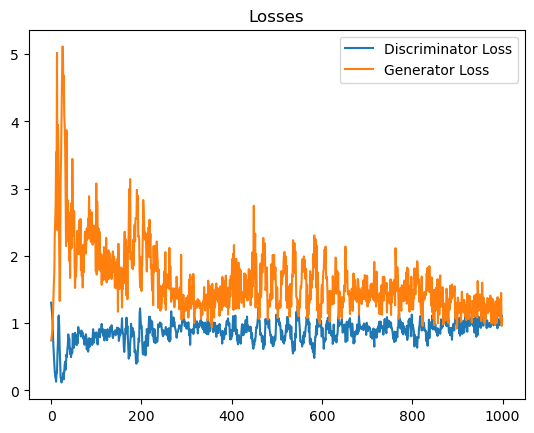

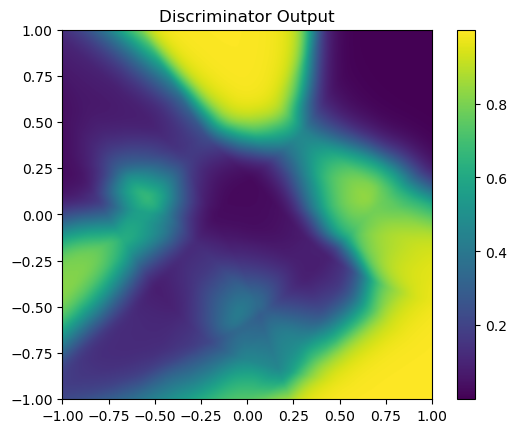

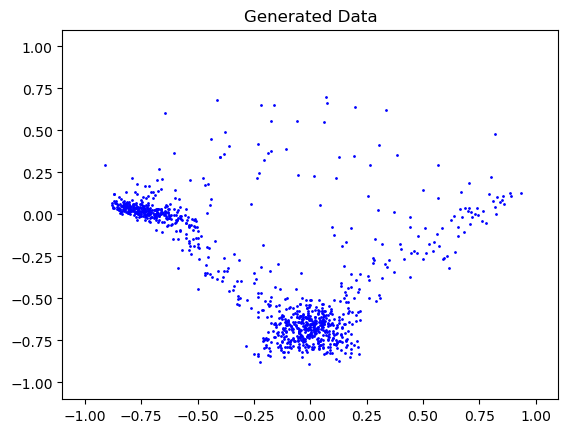

In [78]:
visualize_loss(loss_D_values, loss_G_values)
visualize_discriminator(discriminator)
visualize_generator(generator, noise_dim)

# 3. GAN on MNIST

We will now implement a GAN to generate handwritten digits from the MNIST dataset. The MNIST dataset consists of 28x28 grayscale images of handwritten digits from 0 to 9. We will use the same architectyre as before. For compuational reasons, we will use a rescaled version of the MNIST dataset with images of size 'size'x'size'.

In [79]:
size = 14

The code below loads the MNIST dataset and rescales the images to the desired size.

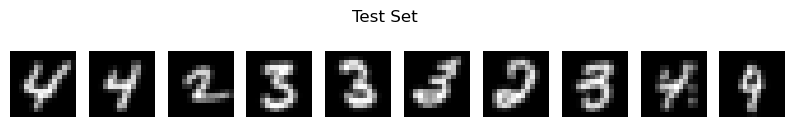

In [80]:
# Transform to resize, convert to tensor, and flatten to a vector of size (size)
transform = transforms.Compose(
    [
        transforms.Resize((size, size)),  # Resize to sizexsize pixels
        transforms.ToTensor(),  # Convert to a tensor with shape (1, size, size)
        transforms.Lambda(
            lambda x: x.view(size * size)
        ),  # Flatten to (size*size,) and normalize
        transforms.Lambda(
            lambda x: 2 * x - 1
        ),  # Normalize to [-1, 1] to avoid overflow
    ]
)


# Custom dataset to filter only labels 0 and 1
class FilteredMNIST(datasets.MNIST):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Filter to keep only images with labels 0 and 1
        indices = [
            i for i, label in enumerate(self.targets) if label in [0, 1, 2, 3, 4]
        ]
        self.data = self.data[indices]
        self.targets = self.targets[indices]

    def __getitem__(self, index):
        # Return only the image, not the label
        image, _ = super().__getitem__(index)
        return image


# Create datasets and loaders
dataset_train = FilteredMNIST(
    root="./data", train=True, download=True, transform=transform
)
dataset_test = FilteredMNIST(
    root="./data", train=False, download=True, transform=transform
)

loader_train = torch.utils.data.DataLoader(dataset_train, batch_size=128, shuffle=True)
loader_test = torch.utils.data.DataLoader(dataset_test, batch_size=128, shuffle=True)

first_batch = next(iter(loader_test))

plt.figure(1, figsize=(10, 10))
plt.suptitle("Test Set", y=0.57)
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(first_batch[i].view(size, size).numpy(), cmap="gray")
    plt.axis("off")
plt.show()

The function below will plot the generated samples from the generator.

In [81]:
def plot_images(generator, noise_dim):
    generator.eval()
    noise = input_noise(10, noise_dim=noise_dim).to(device)
    generated_images = generator(noise).detach().cpu()
    generated_images = (generated_images + 1) / 2
    plt.figure(figsize=(10, 1))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(generated_images[i].view(size, size).numpy(), cmap="gray")
        plt.axis("off")
    plt.show()

As usual for image data, we will split the data into batches of size `batch_size`. The training loop must be adapted to train the GAN on image data. 

<font color='blue'>**TODO:**</font> Complete the code below to implement the training loop for the GAN on MNIST. At each epoch, we iterate over the batches of the dataset and train the GAN.

In [ ]:
def train_GAN_MNIST(
    generator,
    discriminator,
    optimizer_D,
    optimizer_G,
    noise_dim,
    n_epochs=20,
    num_steps=1,
):
    loss_D_values = []
    loss_G_values = []

    for epoch in range(n_epochs):
        avg_loss_D = 0
        avg_loss_G = 0

        for data in loader_train:
            data = data.to(device)
            noise = input_noise(len(data), noise_dim=noise_dim).to(device) # len(data) is the batch size

            loss_D, loss_G = training_step(
                generator, discriminator, optimizer_D, optimizer_G, noise, data, num_steps
            )

            loss_D_values.append(loss_D)
            loss_G_values.append(loss_G)
            avg_loss_D += loss_D
            avg_loss_G += loss_G

        print(
            f"Epoch {epoch+1}/{n_epochs} Loss D: {avg_loss_D/len(loader_train):.4f} Loss G: {avg_loss_G/len(loader_train):.4f}"
        )
        if epoch % 5 == 0:
            plot_images(generator, noise_dim)

    return loss_D_values, loss_G_values

<font color='blue'>**TODO:**</font> Run the code below to train the GAN on MNIST.

Epoch 1/100 Loss D: 0.7245 Loss G: 3.4294


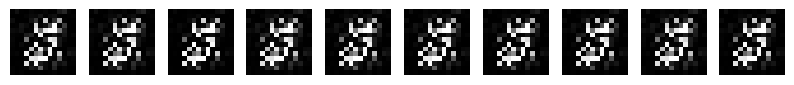

Epoch 2/100 Loss D: 0.1814 Loss G: 5.0450
Epoch 3/100 Loss D: 0.8590 Loss G: 2.7222
Epoch 4/100 Loss D: 0.5844 Loss G: 3.5118
Epoch 5/100 Loss D: 0.6082 Loss G: 3.1867
Epoch 6/100 Loss D: 0.4848 Loss G: 4.2772


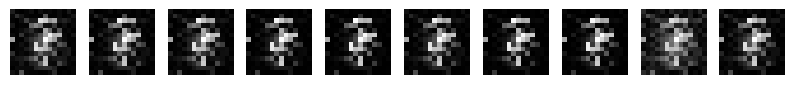

Epoch 7/100 Loss D: 0.6997 Loss G: 2.9620
Epoch 8/100 Loss D: 0.4031 Loss G: 3.7692
Epoch 9/100 Loss D: 0.3695 Loss G: 4.0198
Epoch 10/100 Loss D: 0.3870 Loss G: 4.1878
Epoch 11/100 Loss D: 0.4283 Loss G: 4.2073


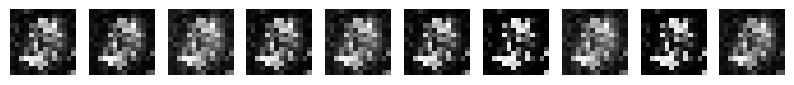

Epoch 12/100 Loss D: 0.4581 Loss G: 4.3383
Epoch 13/100 Loss D: 0.2345 Loss G: 4.9220
Epoch 14/100 Loss D: 0.2708 Loss G: 5.2635
Epoch 15/100 Loss D: 0.4422 Loss G: 4.2120
Epoch 16/100 Loss D: 0.4033 Loss G: 4.3027


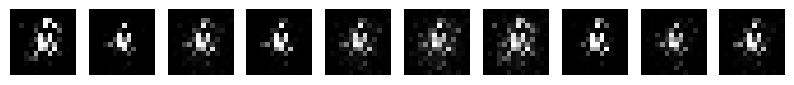

Epoch 17/100 Loss D: 0.4456 Loss G: 3.9881
Epoch 18/100 Loss D: 0.2979 Loss G: 4.0253
Epoch 19/100 Loss D: 0.4137 Loss G: 4.4980
Epoch 20/100 Loss D: 0.4216 Loss G: 3.9141
Epoch 21/100 Loss D: 0.3483 Loss G: 3.6607


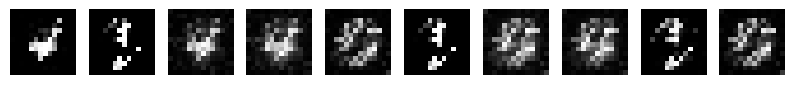

Epoch 22/100 Loss D: 0.3916 Loss G: 4.3346
Epoch 23/100 Loss D: 0.3505 Loss G: 4.8127
Epoch 24/100 Loss D: 0.4265 Loss G: 4.5621
Epoch 25/100 Loss D: 0.3085 Loss G: 4.1037
Epoch 26/100 Loss D: 0.4699 Loss G: 3.9154


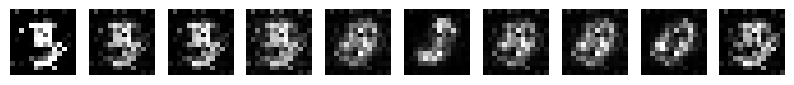

Epoch 27/100 Loss D: 0.5830 Loss G: 3.4935
Epoch 28/100 Loss D: 0.3369 Loss G: 3.1012
Epoch 29/100 Loss D: 0.5977 Loss G: 3.7221
Epoch 30/100 Loss D: 0.6133 Loss G: 3.4037
Epoch 31/100 Loss D: 0.4714 Loss G: 3.1025


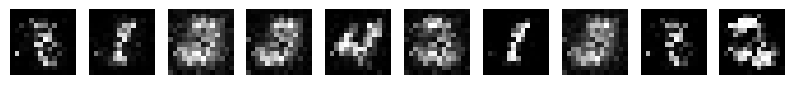

Epoch 32/100 Loss D: 0.5462 Loss G: 3.1769
Epoch 33/100 Loss D: 0.6512 Loss G: 2.7784
Epoch 34/100 Loss D: 0.5824 Loss G: 2.3946
Epoch 35/100 Loss D: 0.6266 Loss G: 2.5404
Epoch 36/100 Loss D: 0.5722 Loss G: 2.7384


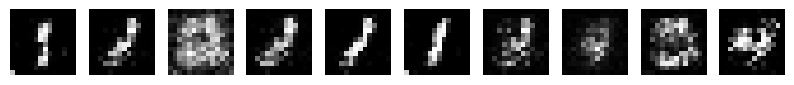

Epoch 37/100 Loss D: 0.6921 Loss G: 2.7904
Epoch 38/100 Loss D: 0.5845 Loss G: 2.2526
Epoch 39/100 Loss D: 0.5146 Loss G: 2.9563
Epoch 40/100 Loss D: 0.7429 Loss G: 2.7805
Epoch 41/100 Loss D: 0.6324 Loss G: 2.3449


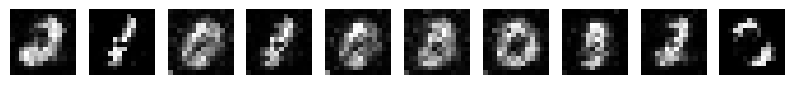

Epoch 42/100 Loss D: 0.5534 Loss G: 2.6333
Epoch 43/100 Loss D: 0.5723 Loss G: 3.0480
Epoch 44/100 Loss D: 0.6249 Loss G: 2.5767
Epoch 45/100 Loss D: 0.5019 Loss G: 2.8265
Epoch 46/100 Loss D: 0.5468 Loss G: 2.7544


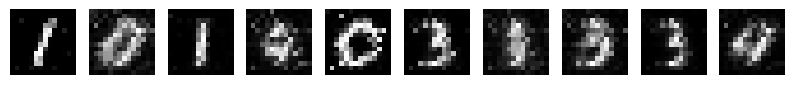

Epoch 47/100 Loss D: 0.6098 Loss G: 2.6896
Epoch 48/100 Loss D: 0.7224 Loss G: 2.9060
Epoch 49/100 Loss D: 0.7816 Loss G: 2.0301
Epoch 50/100 Loss D: 0.6406 Loss G: 2.2002
Epoch 51/100 Loss D: 0.6560 Loss G: 2.1472


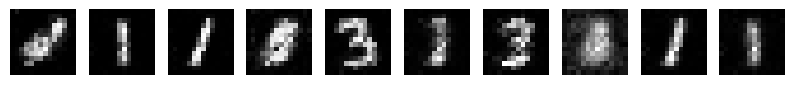

Epoch 52/100 Loss D: 0.6980 Loss G: 2.1798
Epoch 53/100 Loss D: 0.7077 Loss G: 2.1536
Epoch 54/100 Loss D: 0.7177 Loss G: 2.1470
Epoch 55/100 Loss D: 0.7015 Loss G: 2.2119
Epoch 56/100 Loss D: 0.7143 Loss G: 2.2967


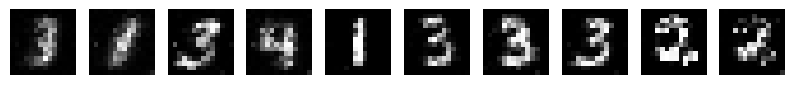

Epoch 57/100 Loss D: 0.7237 Loss G: 2.3518
Epoch 58/100 Loss D: 0.7399 Loss G: 2.1387
Epoch 59/100 Loss D: 0.7142 Loss G: 2.2554
Epoch 60/100 Loss D: 0.8753 Loss G: 2.0731
Epoch 61/100 Loss D: 0.7992 Loss G: 1.9804


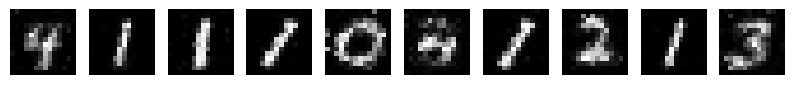

Epoch 62/100 Loss D: 0.8241 Loss G: 1.9225
Epoch 63/100 Loss D: 0.8122 Loss G: 1.9080
Epoch 64/100 Loss D: 0.8366 Loss G: 1.8528
Epoch 65/100 Loss D: 0.8094 Loss G: 1.8836
Epoch 66/100 Loss D: 0.7757 Loss G: 1.9761


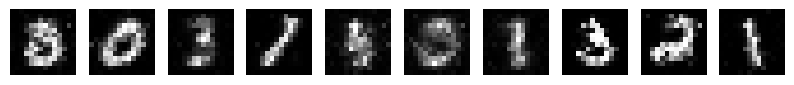

Epoch 67/100 Loss D: 0.8181 Loss G: 1.9861
Epoch 68/100 Loss D: 0.7847 Loss G: 2.0967
Epoch 69/100 Loss D: 0.8268 Loss G: 1.8625
Epoch 70/100 Loss D: 0.8389 Loss G: 1.8461
Epoch 71/100 Loss D: 0.8758 Loss G: 1.7908


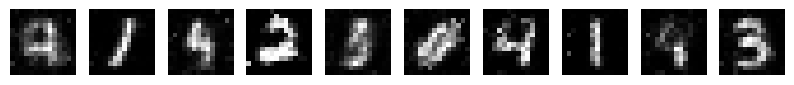

Epoch 72/100 Loss D: 0.8472 Loss G: 1.7342
Epoch 73/100 Loss D: 0.8748 Loss G: 1.6690
Epoch 74/100 Loss D: 0.8564 Loss G: 1.7462
Epoch 75/100 Loss D: 0.9130 Loss G: 1.6320
Epoch 76/100 Loss D: 0.8659 Loss G: 1.7666


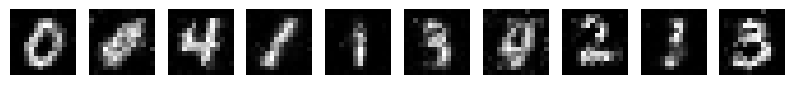

Epoch 77/100 Loss D: 0.8968 Loss G: 1.8260
Epoch 78/100 Loss D: 0.9206 Loss G: 1.6809
Epoch 79/100 Loss D: 0.8969 Loss G: 1.6740
Epoch 80/100 Loss D: 0.9273 Loss G: 1.6728
Epoch 81/100 Loss D: 0.9682 Loss G: 1.5959


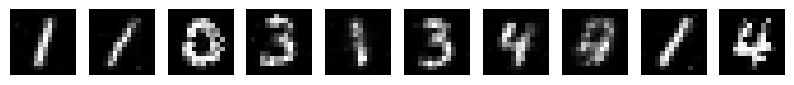

Epoch 82/100 Loss D: 0.9580 Loss G: 1.4555
Epoch 83/100 Loss D: 0.9726 Loss G: 1.5825
Epoch 84/100 Loss D: 0.9178 Loss G: 1.5877
Epoch 85/100 Loss D: 0.9490 Loss G: 1.5805
Epoch 86/100 Loss D: 0.9884 Loss G: 1.3427


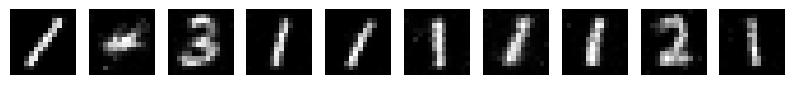

Epoch 87/100 Loss D: 0.9348 Loss G: 1.4932
Epoch 88/100 Loss D: 0.9544 Loss G: 1.5219
Epoch 89/100 Loss D: 0.9700 Loss G: 1.5161
Epoch 90/100 Loss D: 0.9320 Loss G: 1.5722
Epoch 91/100 Loss D: 1.0592 Loss G: 1.3859


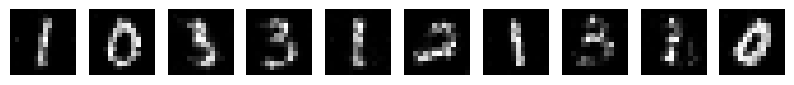

Epoch 92/100 Loss D: 1.0107 Loss G: 1.4143
Epoch 93/100 Loss D: 1.0033 Loss G: 1.4023
Epoch 94/100 Loss D: 1.0239 Loss G: 1.4860
Epoch 95/100 Loss D: 1.0432 Loss G: 1.3099
Epoch 96/100 Loss D: 1.0576 Loss G: 1.3223


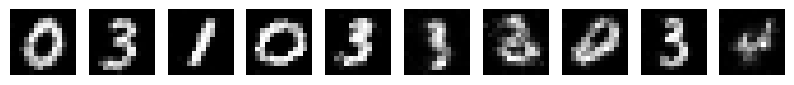

Epoch 97/100 Loss D: 1.0585 Loss G: 1.3504
Epoch 98/100 Loss D: 1.0720 Loss G: 1.3478
Epoch 99/100 Loss D: 1.1015 Loss G: 1.2655
Epoch 100/100 Loss D: 1.0881 Loss G: 1.1975


In [90]:
noise_dim = 100
generator = DenseGenerator(noise_dim, out_dim=size * size).to(device)
discriminator = DenseDiscriminator(in_dim=size * size).to(device)

optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)

loss_D_values, loss_G_values = train_GAN_MNIST(
    generator,
    discriminator,
    optimizer_D,
    optimizer_G,
    noise_dim,
    n_epochs=100,
    num_steps=1,
)

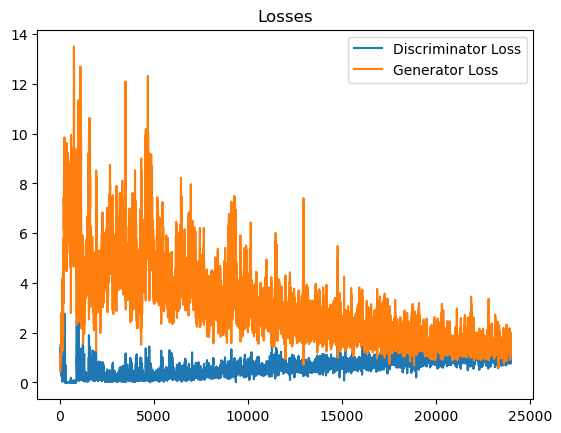

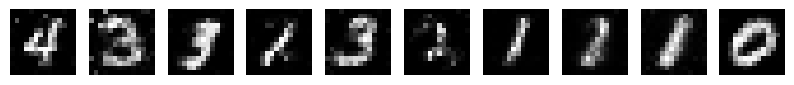

In [85]:
visualize_loss(loss_D_values, loss_G_values)
plot_images(generator, noise_dim)